# Best-subset Selection

### Reproducing Hastie, Tibshirani and Friedman (2009), section 3.3.1

There are two reasons why we are often not satisfied with the least squares
estimates.

- The first is prediction accuracy: the least squares estimates often have
low bias but large variance. Prediction accuracy can sometimes be
improved by shrinking or setting some coeﬃcients to zero. By doing
so we sacrifice a little bit of bias to reduce the variance of the predicted
values, and hence may improve the overall prediction accuracy.

- The second reason is interpretation. With a large number of predic-
tors, we often would like to determine a smaller subset that exhibit
the strongest eﬀects. In order to get the “big picture,” we are willing
to sacrifice some of the small details.

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import scipy.stats as stats
import numpy as np
import itertools
import matplotlib.pyplot as plt


     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519   
5  0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564   

  train  
1     T  
2     T  
3     T  
4     T  
5     T  
          lcavol    lweight        age       lbph        svi        lcp  \
count  97.000000  97.000000  97.000000  97.000000  97.000000  97.000000   
mean    1.350010   3.628943  63.865979   0.100356   0.216495  -0.179366   
std     1.178625   0.428411   7.445117   1.450807   0.413995   1.398250   
min    -1.347074   2.374906  41.000000  -1.386294   0.000000  -1.386294   
25%     0.512824   3.375880  60.000000  -1.386294   0.000000  -1.386294   
50%

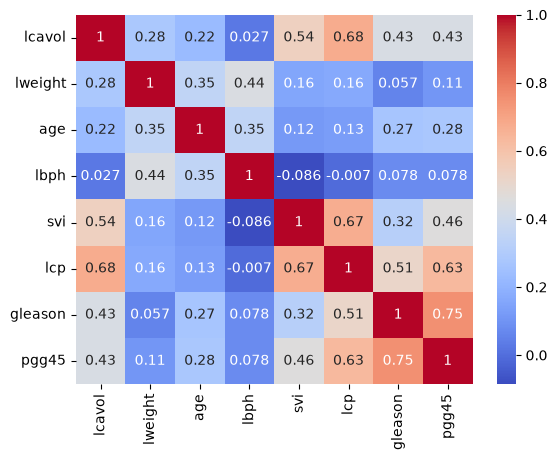

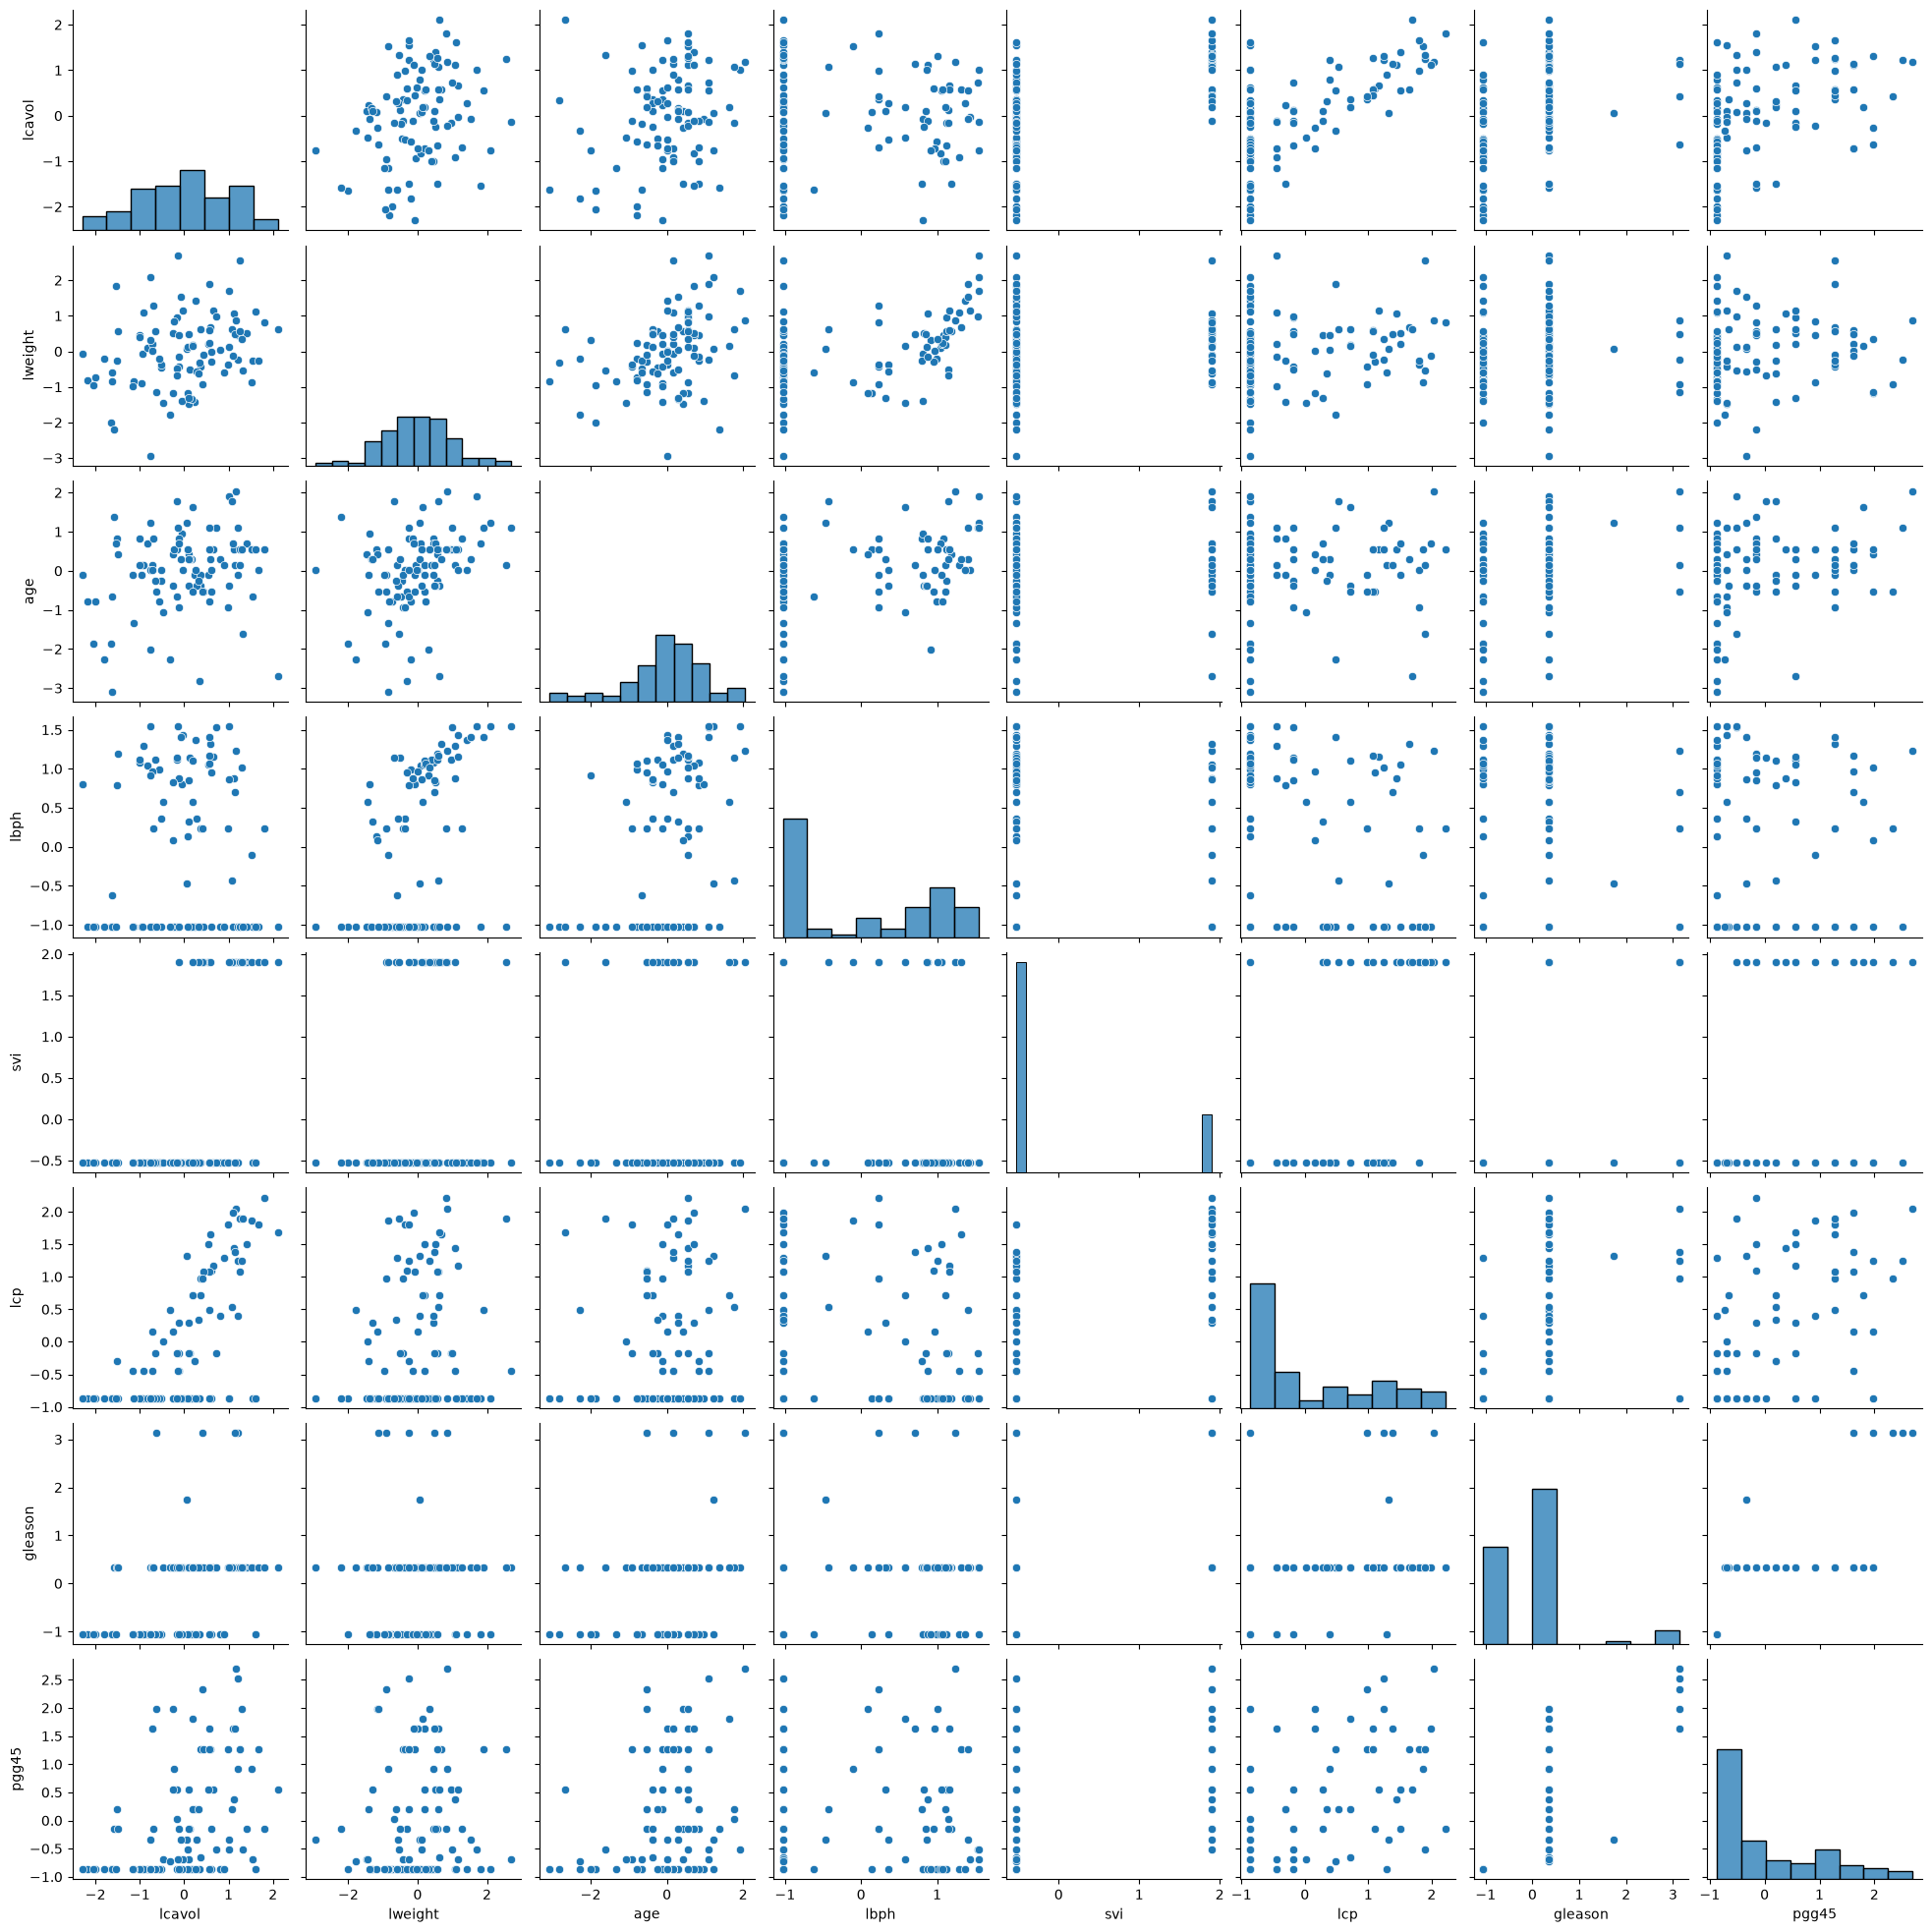

In [3]:
df = pd.read_csv('Linear Regression/prostate.data.txt', sep=r'\s+', index_col=0)

# Display the dataframe
print(df.head())
print(df.describe())

# Examine the relation between the features using a correlation matrix and scatter plots
cols = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]

# we standardize the features 
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

correlations = df[cols].corr()
sns.heatmap(correlations, annot=True, cmap="coolwarm")

sns.pairplot(df[cols])

In [4]:
# split the data into training and testing sets based on the train column already provided in the dataset
train_data = df[df['train'] == 'T']
print(train_data.shape[0])
test_data  = df[df['train'] != 'T']   # or df[df['train'] == 'F'] if strictly 'F'
print(test_data.shape[0])


# Define features and target
X_train = train_data[cols]            # design matrix without the constant column
X_train_with_const = sm.add_constant(X_train) # Add a column of ones for the intercept

y_train = train_data['lpsa']          # target variable

# Fit the OLS model
model = sm.OLS(y_train, X_train_with_const).fit()

# 3. View summary (includes coefficients, p‑values, R², etc.)
print(model.summary())

67
30
                            OLS Regression Results                            
Dep. Variable:                   lpsa   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     16.47
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           2.04e-12
Time:                        15:28:35   Log-Likelihood:                -67.505
No. Observations:                  67   AIC:                             153.0
Df Residuals:                      58   BIC:                             172.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4649      0.089     27.598   

In [9]:
predictors = cols # Predictor names

results = [] # initialize an empty list
# that list will store one dictionary for each model, containing the subset size, predictors, and fit statistics.

for k in range(1, len(predictors) + 1): # Loop over subset sizes

    # Every combination of k predictors
    for subset in itertools.combinations(predictors, k):

        X = X_train[list(subset)] # keep only the columns in the current subset
        X = sm.add_constant(X) # add a constant to the associated design matrix

        model = sm.OLS(y_train, X).fit() # OLS for that subset on the train target

        results.append({ # dictionary we talked about just before
            'k': k,
            'predictors': subset,
            'RSS': model.ssr,
            'R2': model.rsquared,
            'Adj_R2': model.rsquared_adj
        })

# convert the list of dictionaries to a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Best model for each subset size
best_models = (
    results_df.loc[results_df.groupby('k')['RSS'].idxmin()]
    .sort_values('k')
)

# print the best models for each subset size (k, features, RSS)
print(best_models[['k','predictors','RSS']])

     k                                         predictors        RSS
0    1                                          (lcavol,)  44.528583
8    2                                  (lcavol, lweight)  37.091846
38   3                             (lcavol, lweight, svi)  34.907749
97   4                       (lcavol, lweight, lbph, svi)  32.814995
174  5                (lcavol, lweight, lbph, svi, pgg45)  32.069447
229  6           (lcavol, lweight, lbph, svi, lcp, pgg45)  30.539778
247  7      (lcavol, lweight, age, lbph, svi, lcp, pgg45)  29.437300
254  8  (lcavol, lweight, age, lbph, svi, lcp, gleason...  29.426384


Best subset regression finds for each $k\in\{0,1,2,...,p\}$ the subset of size k
that gives smallest residual sum of squares. 

An eﬃcient algorithm-the leaps and bounds procedure (Furnival and Wilson, 1974)—makes this
feasible for $p$ as large as 30 or 40. 

The figure below shows all the subset models for the prostate cancer example. 
The lower boundary represents the models that are eligible for selection by the best-subsets approach. Note that the
best subset of size 2, for example, need not include the variable that was
in the best subset of size 1.

The best-subset curve (red lower boundary) is decreasing by construction, so cannot be used to select the subset size $k$. 
The question of how to choose $k$ involves the tradeoﬀ between bias and variance, along with
the more subjective desire for parsimony. 

There are a number of criteria
that one may use; typically we choose the smallest model that minimizes
an estimate of the expected prediction error.

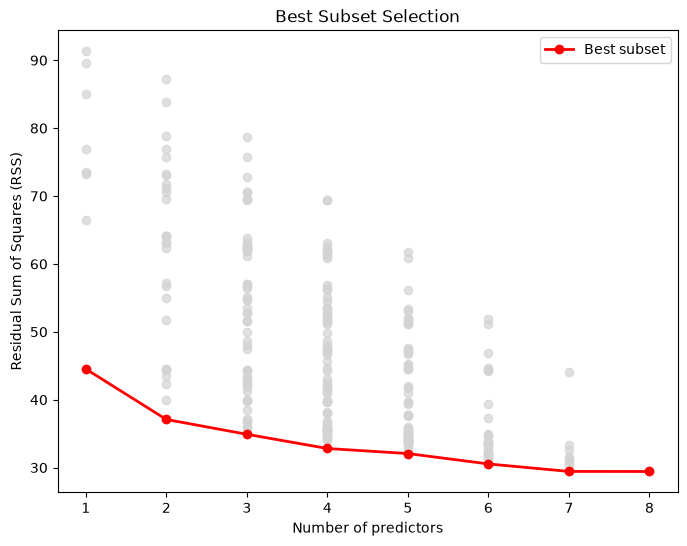

In [10]:
plt.figure(figsize=(8,6))

# Plot RSS of every model
for k in range(1, len(predictors)+1):
    rss = results_df.loc[results_df['k']==k, 'RSS'] # extract all the RSS values for the current subset size
    plt.scatter([k]*len(rss), rss, 
                color='lightgray', alpha=0.7) # place each RSS value on y-axis against the same k on the x-axis

# Plot best subset curve
plt.plot(best_models['k'],
         best_models['RSS'],
         color='red',
         marker='o',
         linewidth=2,
         label='Best subset')

plt.xlabel("Number of predictors")
plt.ylabel("Residual Sum of Squares (RSS)")
plt.title("Best Subset Selection")
plt.legend()
plt.show()

Rather than search through all possible subsets (which becomes infeasible
for $p$ much larger than 40), we can seek a good path through them. We will look at different methods about how to do this. 